# Tugas 2 — K-Means Clustering + Elbow Method

**Mata Kuliah:** Data Mining

## Deskripsi
Implementasi algoritma **K-Means** pada data 10 record dengan atribut **umur** dan **penghasilan (income)**.

1. Hitung manual untuk **K = 2** (ditampilkan langkah per iterasi).
2. Hitung untuk **K = 3, 4, 5, 6** menggunakan program.
3. Visualisasi **Elbow Method** untuk menentukan K optimal.
4. Analisis kualitas klaster di tiap nilai K.

## 1. Library & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Data 10 record (umur, income) — income dalam jutaan Rupiah / bulan
data = pd.DataFrame({
    'ID':     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Umur':   [25, 30, 22, 45, 50, 28, 40, 55, 35, 60],
    'Income': [3, 5, 2, 8, 12, 4, 7, 15, 6, 18],
})
data

,ID,Umur,Income
0,1,25,3
1,2,30,5
2,3,22,2
3,4,45,8
4,5,50,12
5,6,28,4
6,7,40,7
7,8,55,15
8,9,35,6
9,10,60,18


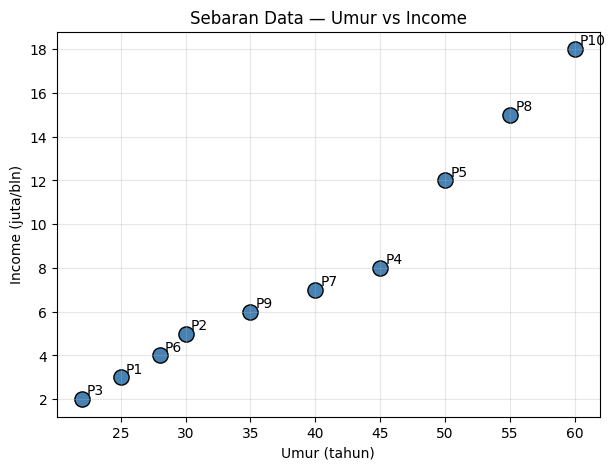

In [2]:
X = data[['Umur', 'Income']].values

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=120, c='steelblue', edgecolors='k')
for i, row in data.iterrows():
    plt.annotate(f"P{row['ID']}", (row['Umur'] + 0.4, row['Income'] + 0.2))
plt.xlabel('Umur (tahun)')
plt.ylabel('Income (juta/bln)')
plt.title('Sebaran Data — Umur vs Income')
plt.grid(alpha=0.3)
plt.show()

## 2. Hitung Manual untuk K = 2

Langkah K-Means:
1. Pilih 2 centroid awal (di sini: data point pertama dan terakhir).
2. Hitung jarak setiap titik ke kedua centroid (Euclidean).
3. Assign titik ke centroid terdekat.
4. Update centroid = rata-rata anggota klaster.
5. Ulangi sampai centroid tidak berubah.

In [3]:
def euclid(a, b):
    return np.sqrt(np.sum((np.array(a) - np.array(b)) ** 2))

def kmeans_manual(X, centroids_awal, max_iter=20):
    centroids = np.array(centroids_awal, dtype=float)
    history = []
    for it in range(max_iter):
        # Step assign
        labels = []
        for x in X:
            jarak = [euclid(x, c) for c in centroids]
            labels.append(int(np.argmin(jarak)))
        labels = np.array(labels)
        history.append({'iter': it + 1, 'centroids': centroids.copy(), 'labels': labels.copy()})
        # Step update
        new_centroids = np.array([
            X[labels == k].mean(axis=0) if (labels == k).any() else centroids[k]
            for k in range(len(centroids))
        ])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return centroids, labels, history

centroids_awal = [X[0], X[-1]]  # P1 dan P10
centroids2, labels2, hist2 = kmeans_manual(X, centroids_awal)

print(f'Konvergen setelah {len(hist2)} iterasi.')
for h in hist2:
    print(f"\nIterasi {h['iter']}:")
    print(f"  Centroid C1 = {h['centroids'][0]}")
    print(f"  Centroid C2 = {h['centroids'][1]}")
    print(f"  Label       = {h['labels']}")

Konvergen setelah 2 iterasi.

Iterasi 1:
  Centroid C1 = [25.  3.]
  Centroid C2 = [60. 18.]
  Label       = [0 0 0 1 1 0 0 1 0 1]

Iterasi 2:
  Centroid C1 = [30.   4.5]
  Centroid C2 = [52.5  13.25]
  Label       = [0 0 0 1 1 0 0 1 0 1]


In [4]:
# Tabel jarak iterasi pertama (untuk perhitungan manual yang dilampirkan)
c1, c2 = centroids_awal
tabel = []
for i, x in enumerate(X):
    d1 = euclid(x, c1)
    d2 = euclid(x, c2)
    tabel.append({
        'Titik': f'P{i+1}',
        'Umur': x[0],
        'Income': x[1],
        f'Jarak ke C1{tuple(c1)}': round(d1, 3),
        f'Jarak ke C2{tuple(c2)}': round(d2, 3),
        'Klaster': 1 if d1 < d2 else 2,
    })
pd.DataFrame(tabel)

,Titik,Umur,Income,"Jarak ke C1(np.int64(25), np.int64(3))","Jarak ke C2(np.int64(60), np.int64(18))",Klaster
0,P1,25,3,0.000,38.079,1
1,P2,30,5,5.385,32.696,1
2,P3,22,2,3.162,41.231,1
3,P4,45,8,20.616,18.028,2
4,P5,50,12,26.571,11.662,2
5,P6,28,4,3.162,34.928,1
6,P7,40,7,15.524,22.825,1
7,P8,55,15,32.311,5.831,2
8,P9,35,6,10.440,27.731,1
9,P10,60,18,38.079,0.000,2


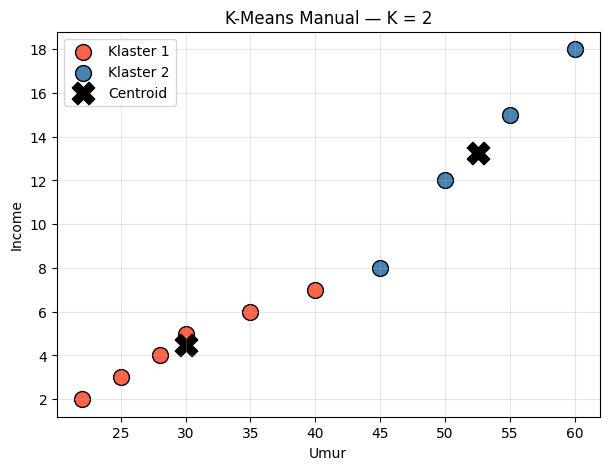

In [5]:
# Visualisasi hasil akhir K=2
plt.figure(figsize=(7, 5))
warna = ['tomato', 'steelblue']
for k in range(2):
    pts = X[labels2 == k]
    plt.scatter(pts[:, 0], pts[:, 1], c=warna[k], s=130, edgecolors='k', label=f'Klaster {k+1}')
plt.scatter(centroids2[:, 0], centroids2[:, 1], marker='X', s=260, c='black', label='Centroid')
plt.xlabel('Umur')
plt.ylabel('Income')
plt.title('K-Means Manual — K = 2')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 3. K-Means Programatik untuk K = 3, 4, 5, 6

Karena skala `Umur` dan `Income` berbeda, dilakukan **standarisasi** terlebih dahulu agar jarak Euclidean tidak didominasi salah satu fitur. SSE/Inertia dilaporkan dalam ruang asli untuk interpretasi yang lebih mudah.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

hasil = {}
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    # SSE pada ruang asli
    centers_asli = scaler.inverse_transform(km.cluster_centers_)
    sse_asli = sum(euclid(X[i], centers_asli[km.labels_[i]]) ** 2 for i in range(len(X)))
    hasil[k] = {
        'model': km,
        'labels': km.labels_,
        'centers_asli': centers_asli,
        'sse_scaled': km.inertia_,
        'sse_asli': sse_asli,
    }
    print(f'K={k}  SSE(scaled)={km.inertia_:.4f}   SSE(asli)={sse_asli:.2f}')

K=2  SSE(scaled)=4.7549   SSE(asli)=506.86
K=3  SSE(scaled)=1.8543   SSE(asli)=161.75
K=4  SSE(scaled)=1.0863   SSE(asli)=110.75
K=5  SSE(scaled)=0.6492   SSE(asli)=63.00


K=6  SSE(scaled)=0.4366   SSE(asli)=37.50


In [7]:
# Tampilkan label per K
df_label = data[['ID', 'Umur', 'Income']].copy()
for k in [2, 3, 4, 5, 6]:
    df_label[f'K={k}'] = hasil[k]['labels']
df_label

,ID,Umur,Income,K=2,K=3,K=4,K=5,K=6
0,1,25,3,0,1,1,1,0
1,2,30,5,0,1,1,3,5
2,3,22,2,0,1,1,1,0
3,4,45,8,0,0,0,0,3
4,5,50,12,1,2,2,2,1
5,6,28,4,0,1,1,1,5
6,7,40,7,0,0,0,0,2
7,8,55,15,1,2,2,2,1
8,9,35,6,0,0,0,3,2
9,10,60,18,1,2,3,4,4


## 4. Visualisasi Klaster K = 3..6

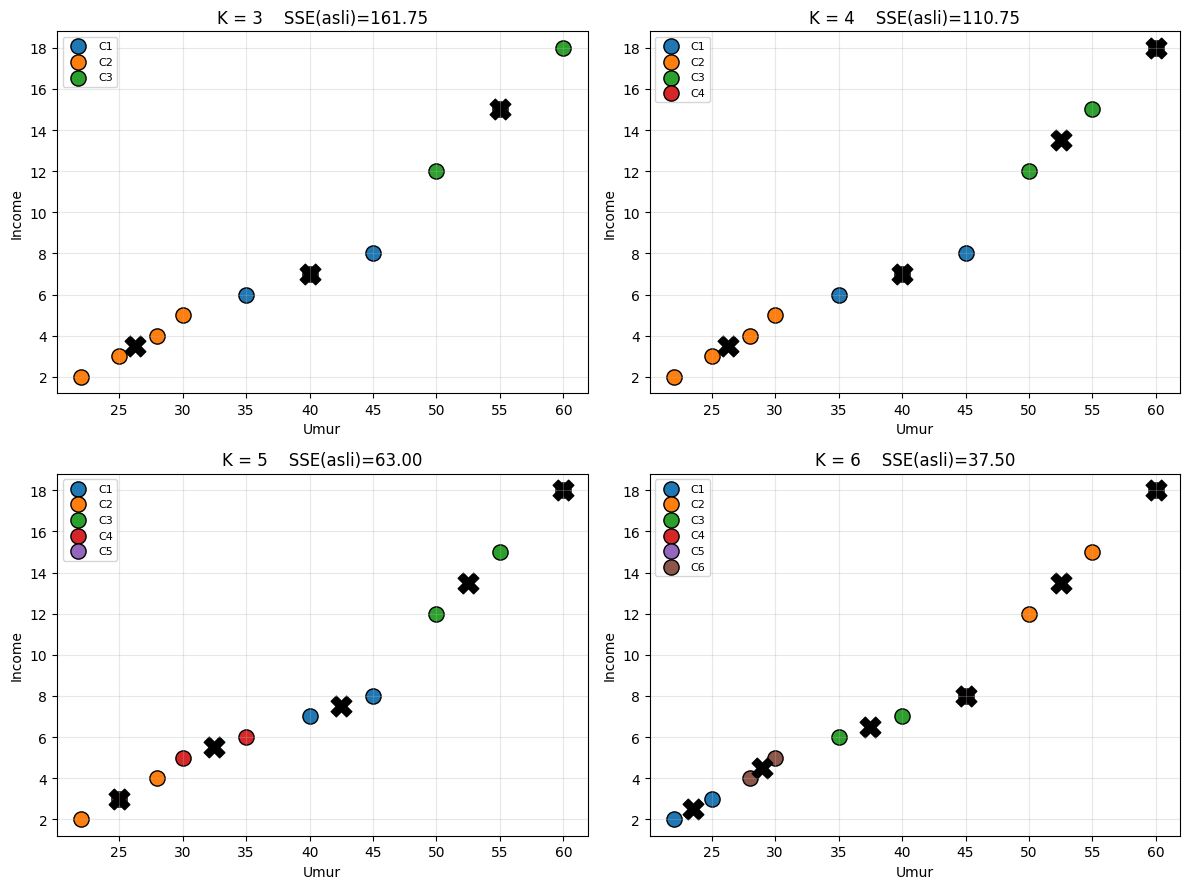

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
for ax, k in zip(axs.flatten(), [3, 4, 5, 6]):
    labels = hasil[k]['labels']
    centers = hasil[k]['centers_asli']
    cmap = plt.get_cmap('tab10')
    for c in range(k):
        pts = X[labels == c]
        ax.scatter(pts[:, 0], pts[:, 1], color=cmap(c), s=120, edgecolors='k', label=f'C{c+1}')
    ax.scatter(centers[:, 0], centers[:, 1], marker='X', c='black', s=220)
    ax.set_title(f'K = {k}    SSE(asli)={hasil[k]["sse_asli"]:.2f}')
    ax.set_xlabel('Umur'); ax.set_ylabel('Income')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Elbow Method

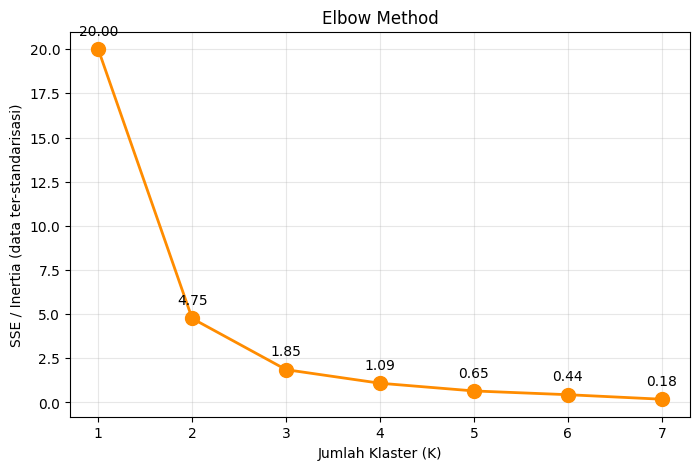

Δ SSE saat K=2: 15.2451
Δ SSE saat K=3: 2.9006
Δ SSE saat K=4: 0.7680
Δ SSE saat K=5: 0.4371
Δ SSE saat K=6: 0.2126
Δ SSE saat K=7: 0.2560


In [9]:
K_range = list(range(1, 8))
sse_list = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    sse_list.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, sse_list, 'o-', linewidth=2, markersize=10, color='darkorange')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('SSE / Inertia (data ter-standarisasi)')
plt.title('Elbow Method')
plt.grid(alpha=0.3)
for k, s in zip(K_range, sse_list):
    plt.annotate(f'{s:.2f}', (k, s), textcoords='offset points', xytext=(0, 10), ha='center')
plt.show()

# Hitung 'siku' otomatis: titik dengan penurunan delta paling tajam
deltas = [sse_list[i-1] - sse_list[i] for i in range(1, len(sse_list))]
for k, d in zip(K_range[1:], deltas):
    print(f'Δ SSE saat K={k}: {d:.4f}')

## 6. Analisis Kualitas Klaster

Cara membaca grafik:
- **K = 1** → semua titik dalam satu klaster, SSE paling besar.
- Saat K bertambah, SSE turun karena titik makin dekat ke centroid masing-masing.
- Pada **siku (elbow)**, penurunan SSE mulai melandai → menambah K tidak banyak menambah informasi.
- Titik siku itulah yang dipilih sebagai **K optimal**.

Untuk dataset ini (10 record, dimensi rendah), elbow umumnya muncul di **K = 3** atau **K = 4** — silakan baca dari grafik & tabel Δ SSE di atas.

Indikasi kualitatif:
- **K = 2** → memisahkan kelompok muda/income-rendah vs tua/income-tinggi.
- **K = 3** → muncul kelompok menengah → biasanya kompromi terbaik.
- **K ≥ 5** → klaster mulai berisi 1–2 anggota saja (over-segmentasi).

## 7. Kesimpulan

1. K-Means K=2 dapat dihitung manual dan konvergen dalam beberapa iterasi.
2. Untuk K=3..6 program lebih efisien daripada hitungan tangan.
3. **Elbow method** menunjukkan titik di mana penambahan klaster tidak lagi memberi penurunan SSE yang signifikan — itulah K terbaik.
4. Standarisasi fitur penting karena `Umur` (puluhan) dan `Income` (angka kecil) berbeda skala.